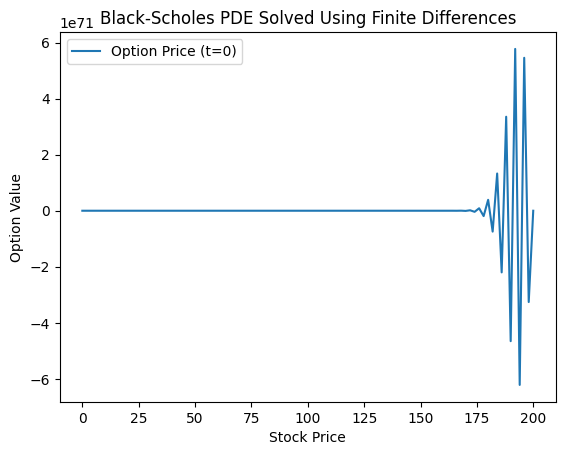

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
S_max = 200  # Maximum stock price
T = 1        # Time to maturity (in years)
r = 0.05     # Risk-free rate
sigma = 0.2  # Volatility
K = 100      # Strike price
N = 100      # Time steps
M = 100      # Price steps
dt = T / N   # Time step size
dS = S_max / M  # Stock price step size

# Grid initialization
V = np.zeros((M+1, N+1))
S = np.linspace(0, S_max, M+1)
t = np.linspace(0, T, N+1)

# Boundary conditions
V[:, -1] = np.maximum(S - K, 0)  # Payoff at maturity
V[0, :] = 0   # If S=0, option value is 0
V[-1, :] = S_max - K * np.exp(-r * (T - t))  # If S is very large

# Explicit finite difference loop
for j in range(N-1, -1, -1):
    for i in range(1, M):
        delta = (V[i+1, j+1] - V[i-1, j+1]) / (2 * dS)
        gamma = (V[i+1, j+1] - 2 * V[i, j+1] + V[i-1, j+1]) / (dS**2)
        theta = -0.5 * sigma**2 * S[i]**2 * gamma - r * S[i] * delta + r * V[i, j+1]
        V[i, j] = V[i, j+1] - dt * theta  # Explicit update

# Plot results
plt.plot(S, V[:, 0], label="Option Price (t=0)")
plt.xlabel("Stock Price")
plt.ylabel("Option Value")
plt.title("Black-Scholes PDE Solved Using Finite Differences")
plt.legend()
plt.show()

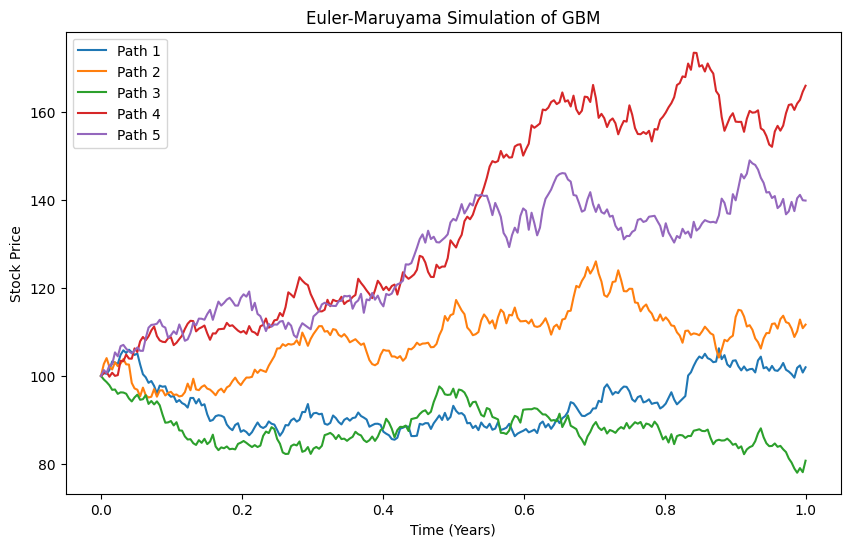

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
S0 = 100      # Initial stock price
mu = 0.05     # Drift (e.g., risk-free rate)
sigma = 0.2   # Volatility
T = 1         # Time horizon (1 year)
N = 252       # Number of time steps (daily)
dt = T / N    # Time step size
M = 5         # Number of simulation paths

# Simulating M paths of GBM
np.random.seed(42)
t = np.linspace(0, T, N+1)
S_paths = np.zeros((M, N+1))
S_paths[:, 0] = S0

for i in range(M):
    for j in range(N):
        Z = np.random.normal(0, 1)  # Standard normal random variable
        S_paths[i, j+1] = S_paths[i, j] + mu * S_paths[i, j] * dt + sigma * S_paths[i, j] * np.sqrt(dt) * Z

# Plot results
plt.figure(figsize=(10, 6))
for i in range(M):
    plt.plot(t, S_paths[i, :], label=f'Path {i+1}')
plt.xlabel("Time (Years)")
plt.ylabel("Stock Price")
plt.title("Euler-Maruyama Simulation of GBM")
plt.legend()
plt.show()